# Data-Driven and Machine-Learning Prediction of 1D Shock-Tube Velocity

Goal: predict the spatiotemporal velocity field u(x,t) from the pressure field p(x,t) for a 1D compressible-flow shock-tube dataset.

Methods compared:

- DMD
- DMD with control, using pressure as the control input
- SINDYc with pressure control
- Ridge regression without lag
- Ridge regression with lagged pressure snapshots
- MLP with lagged pressure snapshots
- LSTM with lagged pressure sequences

## Imports

In [1]:
import time
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import svd
from sklearn.linear_model import Ridge
import pysindy as ps
import torch
import torch.nn as nn

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = Path("project")
OUTPUTS_DIR = Path("outputs_submission")
OUTPUTS_DIR.mkdir(exist_ok=True)

TRAIN_FRACTION = 0.70
DT = 0.1
LAG = 3
SINDYC_THRESHOLD = 0.01
METHOD_ORDER = ["DMD", "DMDc", "SINDYc", "Ridge no lag", "Ridge lag", "MLP", "LSTM"]

MLP_EPOCHS = 500
LSTM_EPOCHS = 500
DEEP_PATIENCE = 12
BATCH_SIZE = 256

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Torch:", torch.__version__)
print("NumPy:", np.__version__)
print("PySINDy:", ps.__version__)

Device: cuda
Torch: 2.8.0+cu128
NumPy: 2.2.6
PySINDy: 2.1.0


## Helper Functions

In [2]:
class ZScore:
    def __init__(self, arr):
        self.mean = float(arr.mean())
        self.std = float(arr.std())
        if self.std < 1e-12:
            self.std = 1.0

    def encode(self, arr):
        return (arr - self.mean) / self.std

    def decode(self, arr):
        return arr * self.std + self.mean


def split_in_time(M, train_fraction=0.70):
    n_train = int(round(M.shape[1] * train_fraction))
    return M[:, :n_train], M[:, n_train:], n_train


def add_noise(M, noise_level, sigma_ref, rng):
    if noise_level == 0:
        return M.copy()
    return M + rng.normal(0.0, noise_level * sigma_ref, size=M.shape)


def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))


def mape_masked(y_true, y_pred, tau=0.01):
    mask = np.abs(y_true) > tau
    if not np.any(mask):
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)


class timed:
    def __enter__(self):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        self.t0 = time.perf_counter()
        return self

    def __exit__(self, *args):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        self.elapsed = time.perf_counter() - self.t0


def set_torch_seed(seed=SEED):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

## Load and Inspect Data

In [3]:
pressure_df = pd.read_csv(DATA_DIR / "pressure.txt", sep=r"\s+", header=None, engine="python")
velocity_df = pd.read_csv(DATA_DIR / "velocity.txt", sep=r"\s+", header=None, engine="python")

assert pressure_df.shape == velocity_df.shape

x = pressure_df.iloc[:, 0].to_numpy()
P = pressure_df.iloc[:, 1:].to_numpy(dtype=np.float64)
U = velocity_df.iloc[:, 1:].to_numpy(dtype=np.float64)

Nx, Nt = U.shape
t = np.arange(Nt) * DT

print("Nx =", Nx)
print("Nt =", Nt)
print("x range = [%.2f, %.2f]" % (x[0], x[-1]))
print("time range = [%.1f, %.1f]" % (t[0], t[-1]))
print("velocity min/max/std = %.4f / %.4f / %.4f" % (U.min(), U.max(), U.std()))
print("pressure min/max/std = %.4f / %.4f / %.4f" % (P.min(), P.max(), P.std()))

Nx = 1001
Nt = 5001
x range = [-10.00, 10.00]
time range = [0.0, 500.0]
velocity min/max/std = -0.4739 / 0.4739 / 0.0476
pressure min/max/std = 0.5501 / 1.4500 / 0.0472


## Visualize the Data

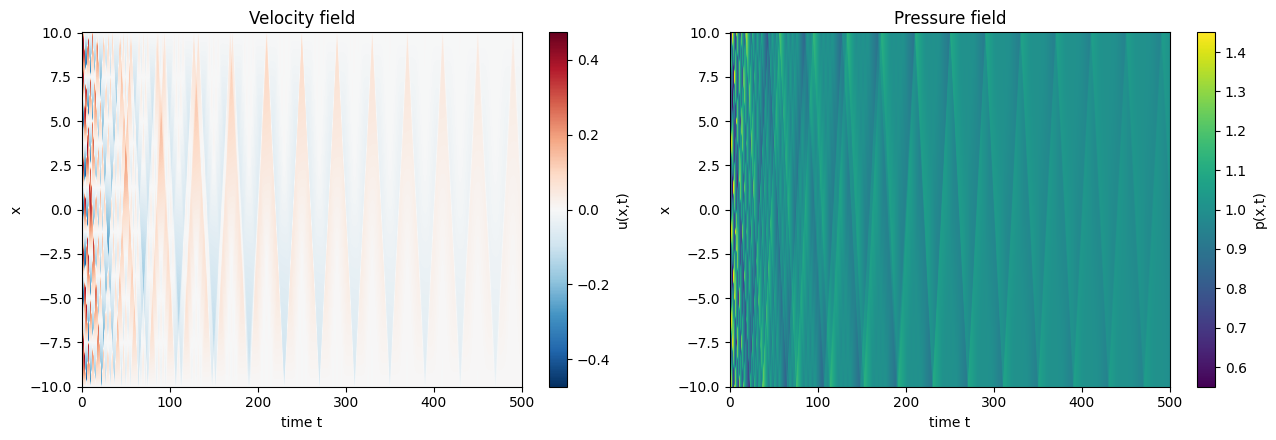

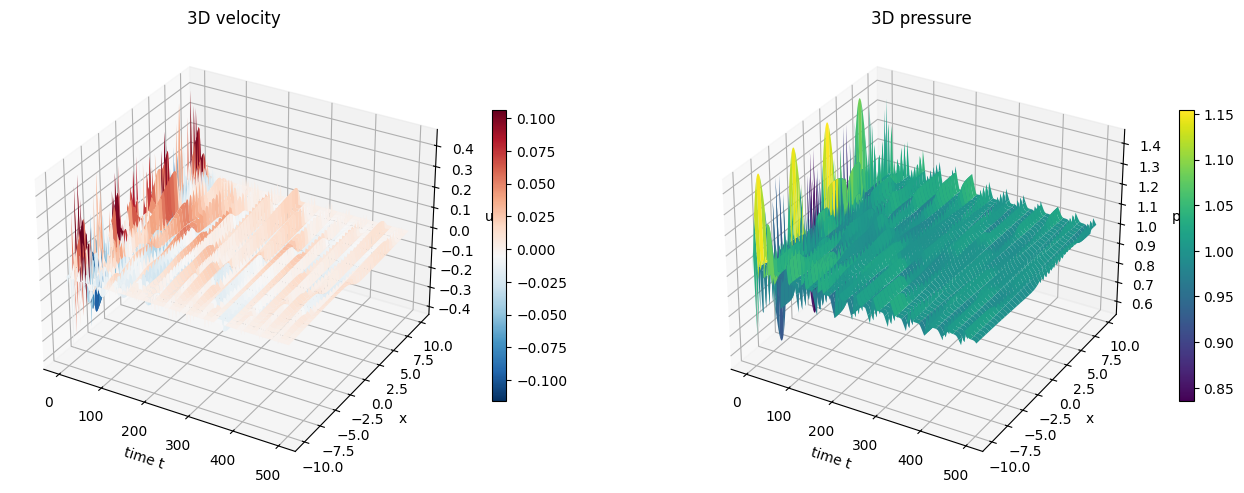

In [4]:
# Space-time heatmaps.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

m0 = axes[0].pcolormesh(t, x, U, cmap="RdBu_r", shading="auto")
fig.colorbar(m0, ax=axes[0], label="u(x,t)")
axes[0].set_title("Velocity field")
axes[0].set_xlabel("time t")
axes[0].set_ylabel("x")

m1 = axes[1].pcolormesh(t, x, P, cmap="viridis", shading="auto")
fig.colorbar(m1, ax=axes[1], label="p(x,t)")
axes[1].set_title("Pressure field")
axes[1].set_xlabel("time t")
axes[1].set_ylabel("x")

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "raw_fields.png", dpi=120)
plt.show()

# 3D view of the same fields, downsampled only for visualization.
t_stride = 25
x_stride = 5
T_mesh, X_mesh = np.meshgrid(t[::t_stride], x[::x_stride])

fig = plt.figure(figsize=(14, 5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
surf = ax.plot_surface(T_mesh, X_mesh, U[::x_stride, ::t_stride], cmap="RdBu_r", linewidth=0)
ax.set_title("3D velocity")
ax.set_xlabel("time t")
ax.set_ylabel("x")
ax.set_zlabel("u")
fig.colorbar(surf, ax=ax, shrink=0.65)

ax = fig.add_subplot(1, 2, 2, projection="3d")
surf = ax.plot_surface(T_mesh, X_mesh, P[::x_stride, ::t_stride], cmap="viridis", linewidth=0)
ax.set_title("3D pressure")
ax.set_xlabel("time t")
ax.set_ylabel("x")
ax.set_zlabel("p")
fig.colorbar(surf, ax=ax, shrink=0.65)

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "data_3d_surfaces.png", dpi=120)
plt.show()

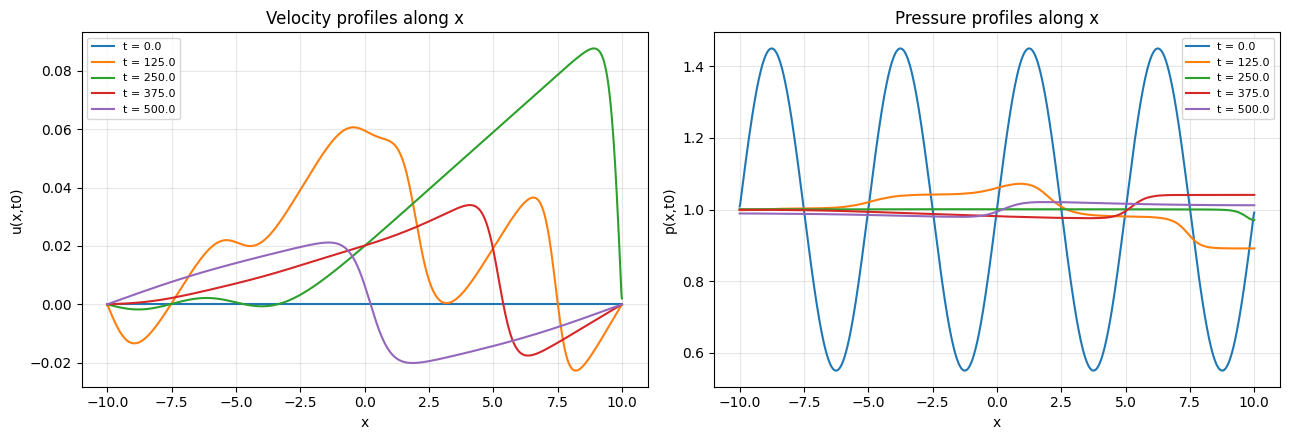

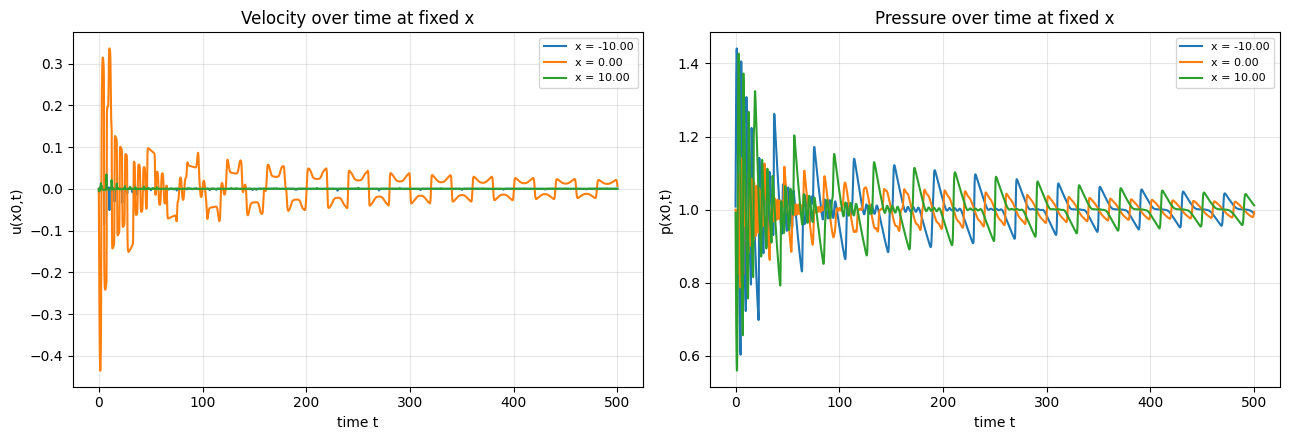

In [5]:
# Spatial profiles at different times.
time_locations = [0, Nt // 4, Nt // 2, 3 * Nt // 4, Nt - 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for j in time_locations:
    axes[0].plot(x, U[:, j], label="t = %.1f" % t[j])
    axes[1].plot(x, P[:, j], label="t = %.1f" % t[j])

axes[0].set_title("Velocity profiles along x")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u(x,t0)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Pressure profiles along x")
axes[1].set_xlabel("x")
axes[1].set_ylabel("p(x,t0)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "data_spatial_profiles.png", dpi=120)
plt.show()

# Time signals at different spatial locations.
x_locations = [0, Nx // 2, Nx - 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for i in x_locations:
    axes[0].plot(t, U[i, :], label="x = %.2f" % x[i])
    axes[1].plot(t, P[i, :], label="x = %.2f" % x[i])

axes[0].set_title("Velocity over time at fixed x")
axes[0].set_xlabel("time t")
axes[0].set_ylabel("u(x0,t)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Pressure over time at fixed x")
axes[1].set_xlabel("time t")
axes[1].set_ylabel("p(x0,t)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "data_time_signals.png", dpi=120)
plt.show()

## Train/Test Split and Normalization

In [6]:
U_train, U_test, n_train = split_in_time(U, TRAIN_FRACTION)
P_train, P_test, _ = split_in_time(P, TRAIN_FRACTION)
t_test = t[n_train:]

u_scaler = ZScore(U_train)
p_scaler = ZScore(P_train)

U_train_norm = u_scaler.encode(U_train)
P_train_norm = p_scaler.encode(P_train)
P_test_norm = p_scaler.encode(P_test)

print("train snapshots =", U_train.shape[1])
print("test snapshots  =", U_test.shape[1])
print("u normalized mean/std = %.3f / %.3f" % (U_train_norm.mean(), U_train_norm.std()))
print("p normalized mean/std = %.3f / %.3f" % (P_train_norm.mean(), P_train_norm.std()))

train snapshots = 3501
test snapshots  = 1500
u normalized mean/std = 0.000 / 1.000
p normalized mean/std = -0.000 / 1.000


## Feature Matrices for Regression and Neural Networks

- Ridge no lag: direct map `p(t) -> u(t)`
- Ridge lag: map `[p(t-3), p(t-2), p(t-1), p(t)] -> u(t)`

The MLP uses the flattened lagged pressure vector. The LSTM uses the same pressure history as a sequence.

In [7]:
def make_lagged_data(P_block, U_block=None, lag=LAG):
    X = []
    for k in range(lag, P_block.shape[1]):
        X.append(np.hstack([P_block[:, k - j] for j in range(lag, -1, -1)]))
    X = np.asarray(X)
    if U_block is None:
        return X
    Y = U_block[:, lag:].T
    return X, Y


def make_lagged_test_data(P_train_norm, P_test_norm, lag=LAG):
    P_all = np.hstack((P_train_norm[:, -lag:], P_test_norm))
    return make_lagged_data(P_all, lag=lag)


def make_sequence_data(P_block, U_block=None, lag=LAG):
    X = []
    for k in range(lag, P_block.shape[1]):
        X.append(P_block[:, k - lag:k + 1].T)
    X = np.asarray(X)
    if U_block is None:
        return X
    Y = U_block[:, lag:].T
    return X, Y


def make_sequence_test_data(P_train_norm, P_test_norm, lag=LAG):
    P_all = np.hstack((P_train_norm[:, -lag:], P_test_norm))
    return make_sequence_data(P_all, lag=lag)

## DMD and DMDc

In [8]:
def fit_dmd(U_train_norm, rank=50):
    X = U_train_norm[:, :-1]
    Xp = U_train_norm[:, 1:]

    U_svd, S, Vt = svd(X, full_matrices=False)
    r = min(rank, len(S))

    Ur = U_svd[:, :r]
    Sr_inv = np.diag(1.0 / S[:r])
    Vr = Vt[:r, :].T

    A_tilde = Ur.T @ Xp @ Vr @ Sr_inv
    eig, W = np.linalg.eig(A_tilde)
    Phi = Xp @ Vr @ Sr_inv @ W

    return {"Phi": Phi, "eig": eig, "rank": r}


def predict_dmd(model, u_last_norm, n_test):
    Phi = model["Phi"]
    eig = model["eig"]
    b = np.linalg.lstsq(Phi, u_last_norm.astype(np.complex128), rcond=None)[0]

    U_pred = np.zeros((Phi.shape[0], n_test))
    powers = eig.copy()
    for k in range(n_test):
        U_pred[:, k] = np.real(Phi @ (powers * b))
        powers = powers * eig
    return U_pred


def fit_dmdc(U_train_norm, P_train_norm, rank=50):
    X = U_train_norm[:, :-1]
    Xp = U_train_norm[:, 1:]
    C = P_train_norm[:, :-1]

    Omega = np.vstack((X, C))
    U_svd, S, Vt = svd(Omega, full_matrices=False)
    r = min(rank, len(S))

    Ur = U_svd[:, :r]
    Sr_inv = np.diag(1.0 / S[:r])
    Vr = Vt[:r, :].T

    G = Xp @ Vr @ Sr_inv @ Ur.T
    nx = X.shape[0]
    A = G[:, :nx]
    B = G[:, nx:]

    return {"A": A, "B": B, "rank": r}


def predict_dmdc(model, u_last_norm, P_train_norm, P_test_norm):
    A = model["A"]
    B = model["B"]
    P_control = np.hstack((P_train_norm[:, -1:], P_test_norm[:, :-1]))

    uk = u_last_norm.copy()
    U_pred = np.zeros((u_last_norm.shape[0], P_test_norm.shape[1]))
    for k in range(P_test_norm.shape[1]):
        uk = A @ uk + B @ P_control[:, k]
        U_pred[:, k] = uk
    return U_pred

## SINDYc

In [9]:
def fit_sindyc(U_train_norm, P_train_norm, dt=DT, r_u=8, r_p=8, threshold=SINDYC_THRESHOLD):
    Phi_u, _, _ = svd(U_train_norm, full_matrices=False)
    Phi_p, _, _ = svd(P_train_norm, full_matrices=False)
    Phi_u = Phi_u[:, :r_u]
    Phi_p = Phi_p[:, :r_p]

    A_train = (Phi_u.T @ U_train_norm).T
    C_train = (Phi_p.T @ P_train_norm).T

    model = ps.SINDy(
        differentiation_method=ps.FiniteDifference(order=1),
        feature_library=ps.PolynomialLibrary(degree=2),
        optimizer=ps.STLSQ(threshold=threshold, alpha=0.1),
    )
    model.fit(A_train, t=dt, u=C_train)

    return {"model": model, "Phi_u": Phi_u, "Phi_p": Phi_p, "r_u": r_u, "r_p": r_p}


def predict_sindyc(bundle, u_last_norm, P_train_norm, P_test_norm, dt=DT):
    model = bundle["model"]
    Phi_u = bundle["Phi_u"]
    Phi_p = bundle["Phi_p"]

    P_control = np.hstack((P_train_norm[:, -1:], P_test_norm[:, :-1]))
    C_test = (Phi_p.T @ P_control).T

    a = (Phi_u.T @ u_last_norm).reshape(1, -1)
    A_pred = np.zeros((P_test_norm.shape[1], a.shape[1]))

    for k in range(P_test_norm.shape[1]):
        da_dt = model.predict(a, u=C_test[k:k + 1])
        a_next = a + dt * da_dt

        if (not np.all(np.isfinite(a_next))) or np.max(np.abs(a_next)) > 1e3:
            A_pred[k:] = A_pred[k - 1] if k > 0 else a.ravel()
            break

        A_pred[k, :] = a_next.ravel()
        a = a_next

    return Phi_u @ A_pred.T

## Ridge Regression

In [10]:
def fit_ridge_no_lag(P_train_norm, U_train_norm, alpha=1.0):
    model = Ridge(alpha=alpha)
    model.fit(P_train_norm.T, U_train_norm.T)
    return model


def predict_ridge_no_lag(model, P_test_norm):
    return model.predict(P_test_norm.T).T


def fit_ridge_lag(P_train_norm, U_train_norm, lag=LAG, alpha=1.0):
    X_train, Y_train = make_lagged_data(P_train_norm, U_train_norm, lag=lag)
    model = Ridge(alpha=alpha)
    model.fit(X_train, Y_train)
    return model


def predict_ridge_lag(model, P_train_norm, P_test_norm, lag=LAG):
    X_test = make_lagged_test_data(P_train_norm, P_test_norm, lag=lag)
    return model.predict(X_test).T

## MLP and LSTM

In [11]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, out_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])


def train_torch_model(model, X_train, Y_train, max_epochs, patience=DEEP_PATIENCE, batch_size=BATCH_SIZE, lr=1e-3):
    n_val = max(1, int(round(0.1 * X_train.shape[0])))

    Xt = torch.tensor(X_train[:-n_val], dtype=torch.float32, device=DEVICE)
    Yt = torch.tensor(Y_train[:-n_val], dtype=torch.float32, device=DEVICE)
    Xv = torch.tensor(X_train[-n_val:], dtype=torch.float32, device=DEVICE)
    Yv = torch.tensor(Y_train[-n_val:], dtype=torch.float32, device=DEVICE)

    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    best_state = None
    best_val = float("inf")
    bad_epochs = 0

    for epoch in range(max_epochs):
        model.train()
        order = torch.randperm(Xt.shape[0], device=DEVICE)

        for start in range(0, Xt.shape[0], batch_size):
            idx = order[start:start + batch_size]
            optimizer.zero_grad()
            loss = loss_fn(model(Xt[idx]), Yt[idx])
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = float(loss_fn(model(Xv), Yv).item())

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    return {"model": model, "epochs": epoch + 1, "best_val": best_val}


def fit_mlp(P_train_norm, U_train_norm, lag=LAG):
    set_torch_seed()
    X_train, Y_train = make_lagged_data(P_train_norm, U_train_norm, lag=lag)
    model = MLP(X_train.shape[1], Y_train.shape[1])
    return train_torch_model(model, X_train, Y_train, max_epochs=MLP_EPOCHS)


def predict_mlp(bundle, P_train_norm, P_test_norm, lag=LAG):
    X_test = make_lagged_test_data(P_train_norm, P_test_norm, lag=lag)
    with torch.no_grad():
        X = torch.tensor(X_test, dtype=torch.float32, device=DEVICE)
        return bundle["model"](X).cpu().numpy().T


def fit_lstm(P_train_norm, U_train_norm, lag=LAG, hidden_dim=64):
    set_torch_seed()
    X_train, Y_train = make_sequence_data(P_train_norm, U_train_norm, lag=lag)
    model = LSTMModel(input_dim=P_train_norm.shape[0], hidden_dim=hidden_dim, out_dim=U_train_norm.shape[0])
    return train_torch_model(model, X_train, Y_train, max_epochs=LSTM_EPOCHS)


def predict_lstm(bundle, P_train_norm, P_test_norm, lag=LAG):
    X_test = make_sequence_test_data(P_train_norm, P_test_norm, lag=lag)
    with torch.no_grad():
        X = torch.tensor(X_test, dtype=torch.float32, device=DEVICE)
        return bundle["model"](X).cpu().numpy().T

## Experiment Runner

In [12]:
def add_result(rows, predictions, method, pred_norm, scaler, U_test_clean, train_time, predict_time, extra):
    pred = scaler.decode(pred_norm)
    predictions[method] = pred
    rows.append([method,mae(U_test_clean, pred),mape_masked(U_test_clean, pred),train_time,predict_time,extra])


def run_all_methods(U_train_raw, P_train_raw, P_test_raw, U_test_clean, run_deep=True):
    u_scaler_local = ZScore(U_train_raw)
    p_scaler_local = ZScore(P_train_raw)

    U_tr = u_scaler_local.encode(U_train_raw)
    P_tr = p_scaler_local.encode(P_train_raw)
    P_te = p_scaler_local.encode(P_test_raw)

    u_last = U_tr[:, -1]
    n_test = U_test_clean.shape[1]

    rows = []
    predictions = {}

    with timed() as tt:
        model = fit_dmd(U_tr, rank=50)
    with timed() as tp:
        pred_norm = predict_dmd(model, u_last, n_test)
    add_result(rows, predictions, "DMD", pred_norm, u_scaler_local, U_test_clean, tt.elapsed, tp.elapsed, "rank=%d" % model["rank"])

    with timed() as tt:
        model = fit_dmdc(U_tr, P_tr, rank=50)
    with timed() as tp:
        pred_norm = predict_dmdc(model, u_last, P_tr, P_te)
    add_result(rows, predictions, "DMDc", pred_norm, u_scaler_local, U_test_clean, tt.elapsed, tp.elapsed, "rank=%d" % model["rank"])

    with timed() as tt:
        model = fit_sindyc(U_tr, P_tr, threshold=SINDYC_THRESHOLD)
    with timed() as tp:
        pred_norm = predict_sindyc(model, u_last, P_tr, P_te)
    add_result(rows, predictions, "SINDYc", pred_norm, u_scaler_local, U_test_clean, tt.elapsed, tp.elapsed, "threshold=%.3g" % SINDYC_THRESHOLD)

    with timed() as tt:
        model = fit_ridge_no_lag(P_tr, U_tr, alpha=1.0)
    with timed() as tp:
        pred_norm = predict_ridge_no_lag(model, P_te)
    add_result(rows, predictions, "Ridge no lag", pred_norm, u_scaler_local, U_test_clean, tt.elapsed, tp.elapsed, "alpha=1.0")

    with timed() as tt:
        model = fit_ridge_lag(P_tr, U_tr, lag=LAG, alpha=1.0)
    with timed() as tp:
        pred_norm = predict_ridge_lag(model, P_tr, P_te, lag=LAG)
    add_result(rows, predictions, "Ridge lag", pred_norm, u_scaler_local, U_test_clean, tt.elapsed, tp.elapsed, "lag=%d,alpha=1.0" % LAG)

    if run_deep:
        with timed() as tt:
            model = fit_mlp(P_tr, U_tr, lag=LAG)
        with timed() as tp:
            pred_norm = predict_mlp(model, P_tr, P_te, lag=LAG)
        add_result(rows, predictions, "MLP", pred_norm, u_scaler_local, U_test_clean, tt.elapsed, tp.elapsed, "lag=%d,epochs=%d" % (LAG, model["epochs"]))

        with timed() as tt:
            model = fit_lstm(P_tr, U_tr, lag=LAG, hidden_dim=64)
        with timed() as tp:
            pred_norm = predict_lstm(model, P_tr, P_te, lag=LAG)
        add_result(rows, predictions, "LSTM", pred_norm, u_scaler_local, U_test_clean, tt.elapsed, tp.elapsed, "lag=%d,epochs=%d" % (LAG, model["epochs"]))

    result = pd.DataFrame(rows, columns=["method", "mae", "mape", "train_time", "predict_time", "extra"])
    return result, predictions

## Plotting Helpers

In [13]:
def plot_mae(results, group_column, xlabel, title, filename):
    fig, ax = plt.subplots(figsize=(8, 5))
    for method in METHOD_ORDER:
        data = results[results["method"] == method]
        if len(data) > 0:
            ax.plot(data[group_column], data["mae"], "o-", label=method)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("MAE")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(OUTPUTS_DIR / filename, dpi=120)
    plt.show()


def plot_point_comparison(t_axis, x, U_true, predictions, x_value=0.0):
    i = int(np.argmin(np.abs(x - x_value)))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t_axis, U_true[i, :], "k", linewidth=2, label="true")
    for method in METHOD_ORDER:
        if method in predictions:
            ax.plot(t_axis, predictions[method][i, :], "--", label=method)
    ax.set_xlabel("time t")
    ax.set_ylabel("u(x0,t)")
    ax.set_title("Prediction at x = %.2f" % x[i])
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


def plot_field_prediction(t_axis, x, U_true, U_pred, title):
    vmax = float(np.max(np.abs(U_true)))
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    m0 = axes[0].pcolormesh(t_axis, x, U_true, cmap="RdBu_r", shading="auto", vmin=-vmax, vmax=vmax)
    fig.colorbar(m0, ax=axes[0], label="u")
    axes[0].set_title("True velocity")
    axes[0].set_xlabel("time t")
    axes[0].set_ylabel("x")

    m1 = axes[1].pcolormesh(t_axis, x, U_pred, cmap="RdBu_r", shading="auto", vmin=-vmax, vmax=vmax)
    fig.colorbar(m1, ax=axes[1], label="predicted u")
    axes[1].set_title(title)
    axes[1].set_xlabel("time t")
    axes[1].set_ylabel("x")

    err = np.abs(U_true - U_pred)
    m2 = axes[2].pcolormesh(t_axis, x, err, cmap="magma", shading="auto")
    fig.colorbar(m2, ax=axes[2], label="absolute error")
    axes[2].set_title("Absolute error")
    axes[2].set_xlabel("time t")
    axes[2].set_ylabel("x")

    fig.tight_layout()
    plt.show()

In [14]:
clean_results, clean_predictions = run_all_methods(U_train,P_train,P_test,U_test,run_deep=True)
clean_results.to_csv(OUTPUTS_DIR / "clean_results.csv", index=False)
clean_results

,method,mae,mape,train_time,predict_time,extra
0,DMD,0.021930,142.331326,0.893756,0.186595,rank=50
1,DMDc,0.002182,11.746715,5.206360,0.528172,rank=50
2,SINDYc,0.003993,21.654466,1.972625,19.890292,threshold=0.01
3,Ridge no lag,0.014405,99.728321,0.109209,0.018631,alpha=1.0
4,Ridge lag,0.000418,2.210318,1.151148,0.091217,"lag=3,alpha=1.0"
5,MLP,0.001732,8.878027,3.805799,0.054388,"lag=3,epochs=73"
6,LSTM,0.007247,40.786351,2.967814,0.028856,"lag=3,epochs=130"


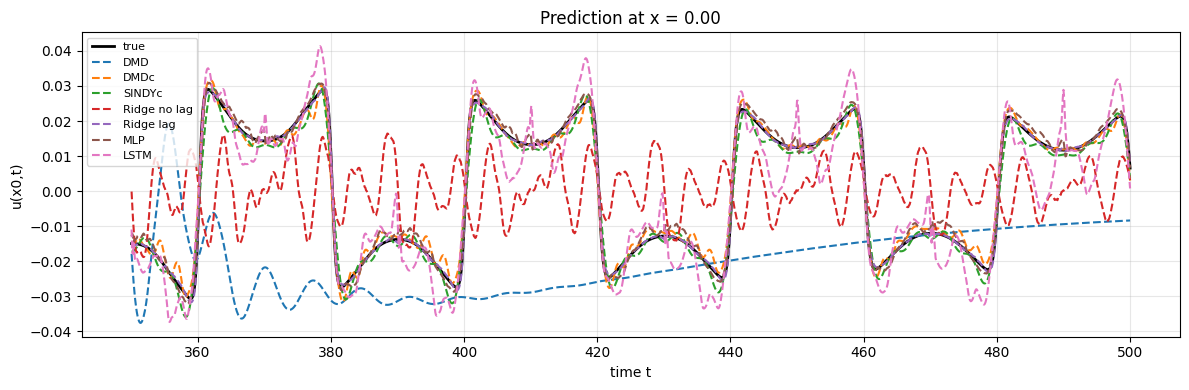

In [15]:
plot_point_comparison(t_test, x, U_test, clean_predictions, x_value=0.0)

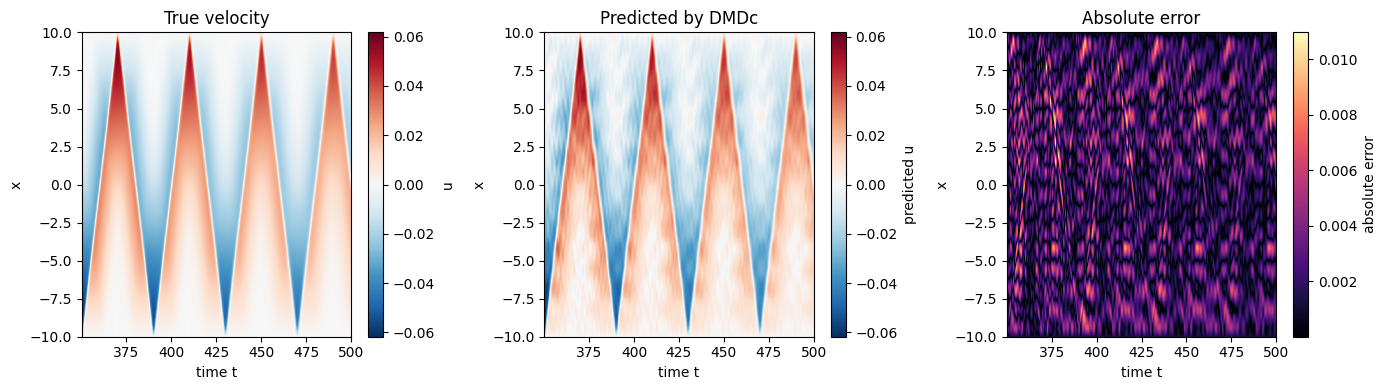

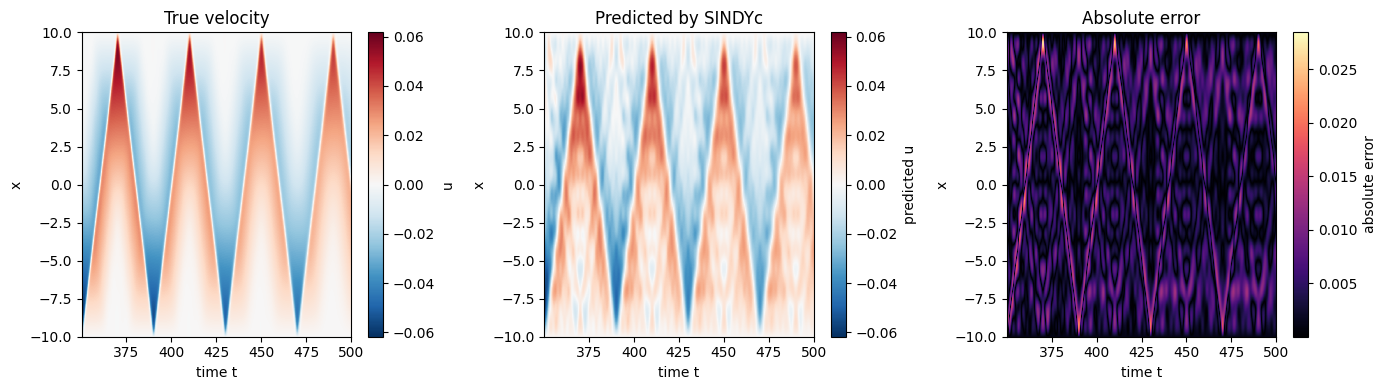

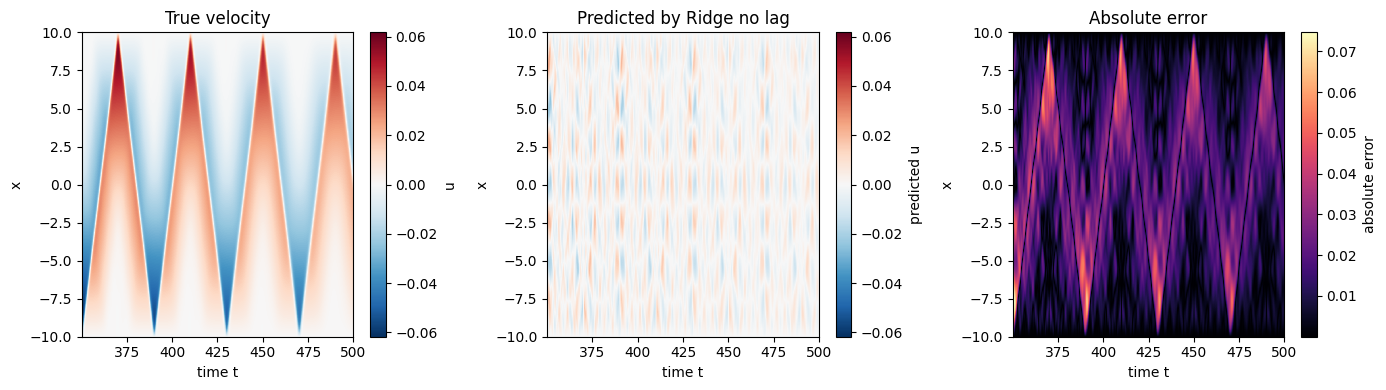

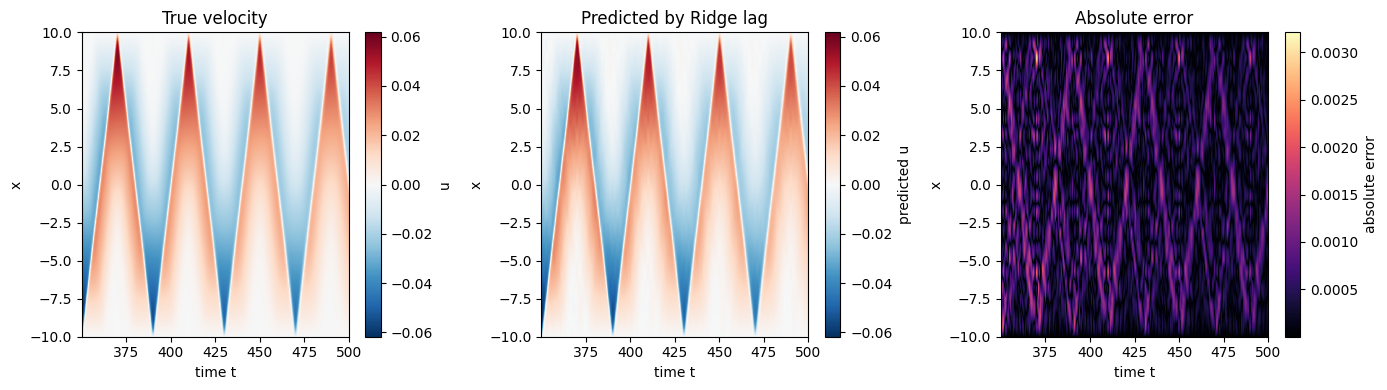

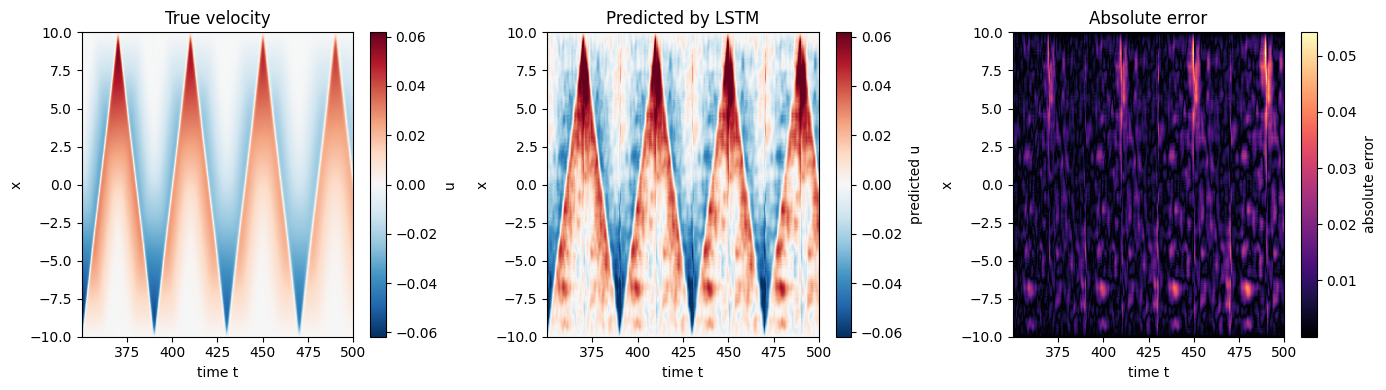

In [16]:
for method in ["DMDc", "SINDYc", "Ridge no lag", "Ridge lag", "LSTM"]:
    if method in clean_predictions:
        plot_field_prediction(t_test, x, U_test, clean_predictions[method], "Predicted by " + method)

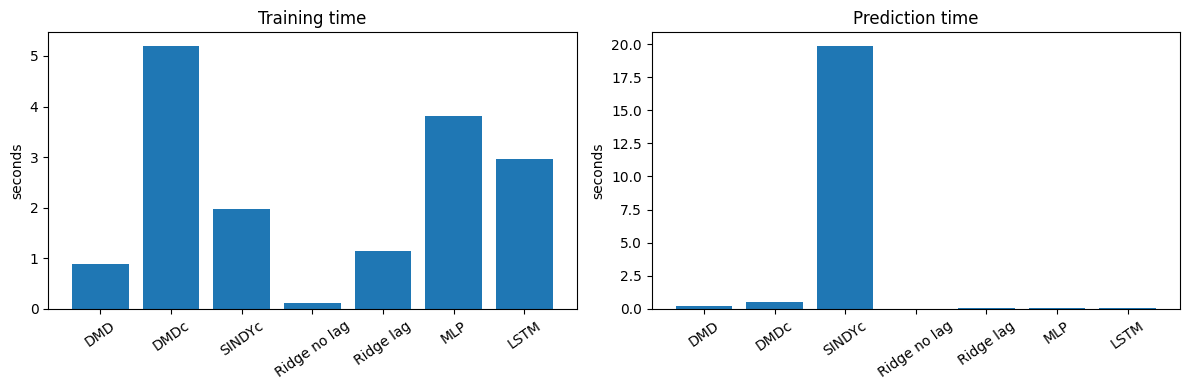

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(clean_results["method"], clean_results["train_time"])
axes[0].set_ylabel("seconds")
axes[0].set_title("Training time")
axes[0].tick_params(axis="x", rotation=35)

axes[1].bar(clean_results["method"], clean_results["predict_time"])
axes[1].set_ylabel("seconds")
axes[1].set_title("Prediction time")
axes[1].tick_params(axis="x", rotation=35)

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "timing_clean.png", dpi=120)
plt.show()

## SINDYc Threshold Sensitivity

In [18]:
threshold_list = np.array([0.001, 0.003, 0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.10])
threshold_rows = []
for threshold in threshold_list:
    model = fit_sindyc(U_train_norm, P_train_norm, threshold=threshold)
    pred_norm = predict_sindyc(model, U_train_norm[:, -1], P_train_norm, P_test_norm)
    pred = u_scaler.decode(pred_norm)
    nonzero_terms = int(np.count_nonzero(np.abs(model["model"].coefficients()) > 1e-12))
    threshold_rows.append([threshold, mae(U_test, pred), mape_masked(U_test, pred), nonzero_terms])

In [19]:
threshold_results = pd.DataFrame(threshold_rows, columns=["threshold", "mae", "mape", "nonzero_terms"])
threshold_results 

,threshold,mae,mape,nonzero_terms
0,0.001,0.005790,34.594027,192
1,0.003,0.006908,33.213895,73
2,0.005,0.004189,22.772108,56
3,0.010,0.003993,21.654466,44
4,0.020,0.004400,23.817641,30
5,0.030,0.005724,31.314844,23
6,0.050,0.006587,37.810087,18
7,0.080,0.006619,38.332499,15
8,0.100,0.006624,38.280090,13


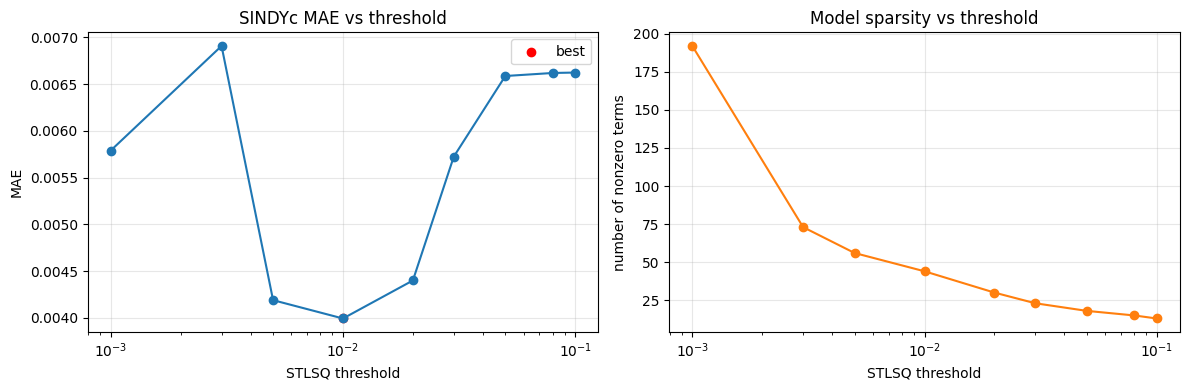

Best threshold from sensitivity test: 0.01
Threshold used in main experiments: 0.01


In [20]:
best_idx = int(threshold_results["mae"].idxmin())
best_threshold = threshold_results.loc[best_idx, "threshold"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(threshold_results["threshold"], threshold_results["mae"], "o-")
axes[0].scatter([best_threshold], [threshold_results.loc[best_idx, "mae"]], color="red", label="best")
axes[0].set_xscale("log")
axes[0].set_xlabel("STLSQ threshold")
axes[0].set_ylabel("MAE")
axes[0].set_title("SINDYc MAE vs threshold")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(threshold_results["threshold"], threshold_results["nonzero_terms"], "o-", color="C1")
axes[1].set_xscale("log")
axes[1].set_xlabel("STLSQ threshold")
axes[1].set_ylabel("number of nonzero terms")
axes[1].set_title("Model sparsity vs threshold")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "sindyc_threshold.png", dpi=120)
plt.show()

print("Best threshold from sensitivity test:", best_threshold)
print("Threshold used in main experiments:", SINDYC_THRESHOLD)

## Noise Robustness Study

In [21]:
NOISE_LEVELS = [0.0, 0.01, 0.05, 0.10]
noise_rows = []
for noise_level in NOISE_LEVELS:
    rng = np.random.default_rng(SEED + int(noise_level * 1000))
    U_train_noisy = add_noise(U_train, noise_level, U_train.std(), rng)
    P_train_noisy = add_noise(P_train, noise_level, P_train.std(), rng)
    P_test_noisy = add_noise(P_test, noise_level, P_train.std(), rng)
    result_i, _ = run_all_methods(U_train_noisy,P_train_noisy,P_test_noisy,U_test,run_deep=True)
    result_i.insert(1, "noise", noise_level)
    noise_rows.append(result_i)

In [22]:
noise_results = pd.concat(noise_rows, ignore_index=True)
noise_results.to_csv(OUTPUTS_DIR / "noise_results.csv", index=False)
noise_results

,method,noise,mae,mape,train_time,predict_time,extra
0,DMD,0.00,0.021930,142.331326,0.857551,0.205461,rank=50
1,DMDc,0.00,0.002182,11.746715,4.674860,0.392327,rank=50
2,SINDYc,0.00,0.003993,21.654466,1.753283,26.661082,threshold=0.01
3,Ridge no lag,0.00,0.014405,99.728321,0.126806,0.022772,alpha=1.0
4,Ridge lag,0.00,0.000418,2.210318,1.250224,0.130032,"lag=3,alpha=1.0"
5,MLP,0.00,0.001732,8.878027,2.659647,0.068198,"lag=3,epochs=73"
6,LSTM,0.00,0.007247,40.786351,4.772544,0.030617,"lag=3,epochs=130"
7,DMD,0.01,0.021906,142.202065,0.801458,0.153311,rank=50
8,DMDc,0.01,0.002183,11.730396,4.455583,0.542006,rank=50
9,SINDYc,0.01,0.003987,21.569133,2.045064,24.414102,threshold=0.01


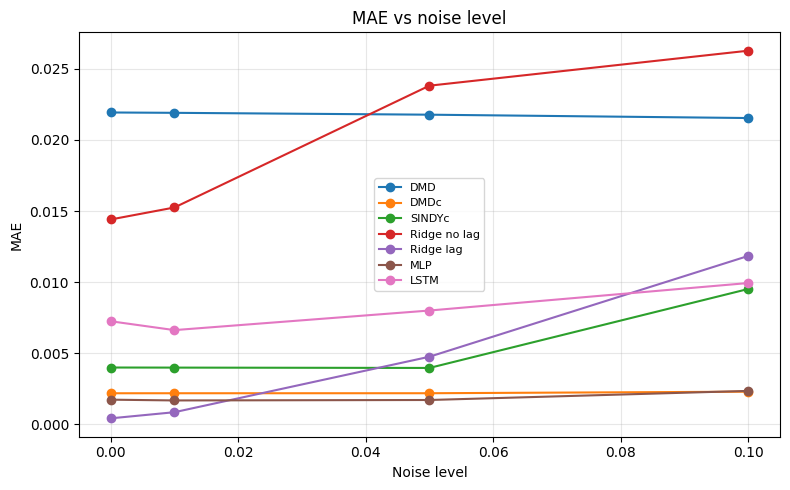

In [23]:
plot_mae(noise_results, "noise", "Noise level", "MAE vs noise level", "mae_vs_noise.png")

## Train/Test Ratio Experiment

In [24]:
TRAIN_FRACTIONS = [0.50, 0.60, 0.70, 0.80]
ratio_rows = []

for train_fraction in TRAIN_FRACTIONS:
    U_train_i, U_test_i, n_train_i = split_in_time(U, train_fraction)
    P_train_i, P_test_i, _ = split_in_time(P, train_fraction)

    print("\nTrain fraction = %.0f%%" % (train_fraction * 100))
    result_i, _ = run_all_methods(U_train_i,P_train_i,P_test_i,U_test_i,run_deep=True)
    result_i.insert(1, "train_fraction", train_fraction)
    result_i.insert(2, "test_fraction", 1.0 - train_fraction)
    result_i.insert(3, "train_snapshots", U_train_i.shape[1])
    result_i.insert(4, "test_snapshots", U_test_i.shape[1])
    ratio_rows.append(result_i)

    print(result_i[["method", "mae"]].round(5))


Train fraction = 50%
         method      mae
0           DMD  0.03686
1          DMDc  0.00339
2        SINDYc  0.00782
3  Ridge no lag  0.01712
4     Ridge lag  0.00060
5           MLP  0.00299
6          LSTM  0.01589

Train fraction = 60%
         method      mae
0           DMD  0.01872
1          DMDc  0.00275
2        SINDYc  0.00528
3  Ridge no lag  0.01561
4     Ridge lag  0.00049
5           MLP  0.00214
6          LSTM  0.01261

Train fraction = 70%
         method      mae
0           DMD  0.02193
1          DMDc  0.00218
2        SINDYc  0.00399
3  Ridge no lag  0.01440
4     Ridge lag  0.00042
5           MLP  0.00173
6          LSTM  0.00725

Train fraction = 80%
         method      mae
0           DMD  0.01544
1          DMDc  0.00184
2        SINDYc  0.00332
3  Ridge no lag  0.01340
4     Ridge lag  0.00037
5           MLP  0.00156
6          LSTM  0.00527


In [26]:
ratio_results = pd.concat(ratio_rows, ignore_index=True)
ratio_results.to_csv(OUTPUTS_DIR / "train_test_ratio_results.csv", index=False)
ratio_results

,method,train_fraction,test_fraction,train_snapshots,test_snapshots,mae,mape,train_time,predict_time,extra
0,DMD,0.5,0.5,2500,2501,0.036865,215.145739,0.681684,0.319594,rank=50
1,DMDc,0.5,0.5,2500,2501,0.003393,17.175052,3.093822,0.861167,rank=50
2,SINDYc,0.5,0.5,2500,2501,0.007822,41.749429,1.598417,52.268459,threshold=0.01
3,Ridge no lag,0.5,0.5,2500,2501,0.017118,100.053854,0.129847,0.049786,alpha=1.0
4,Ridge lag,0.5,0.5,2500,2501,0.000604,2.882666,0.793039,0.202477,"lag=3,alpha=1.0"
5,MLP,0.5,0.5,2500,2501,0.002989,13.595796,2.518848,0.107247,"lag=3,epochs=103"
6,LSTM,0.5,0.5,2500,2501,0.015893,88.147522,0.851235,0.050111,"lag=3,epochs=35"
7,DMD,0.6,0.4,3001,2000,0.018721,95.514702,1.285740,0.297575,rank=50
8,DMDc,0.6,0.4,3001,2000,0.002751,13.997643,5.228292,0.639579,rank=50
9,SINDYc,0.6,0.4,3001,2000,0.005285,26.674235,2.672876,30.084105,threshold=0.01


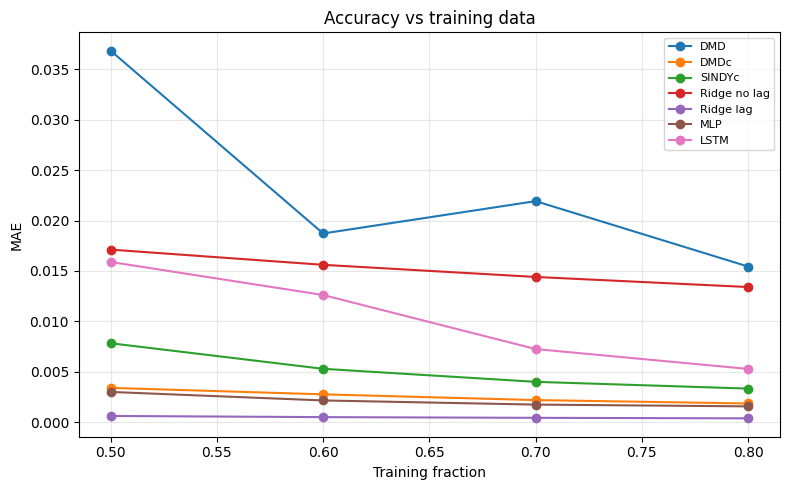

In [27]:
plot_mae(ratio_results,"train_fraction","Training fraction","Accuracy vs training data","train_test_ratio_accuracy.png")

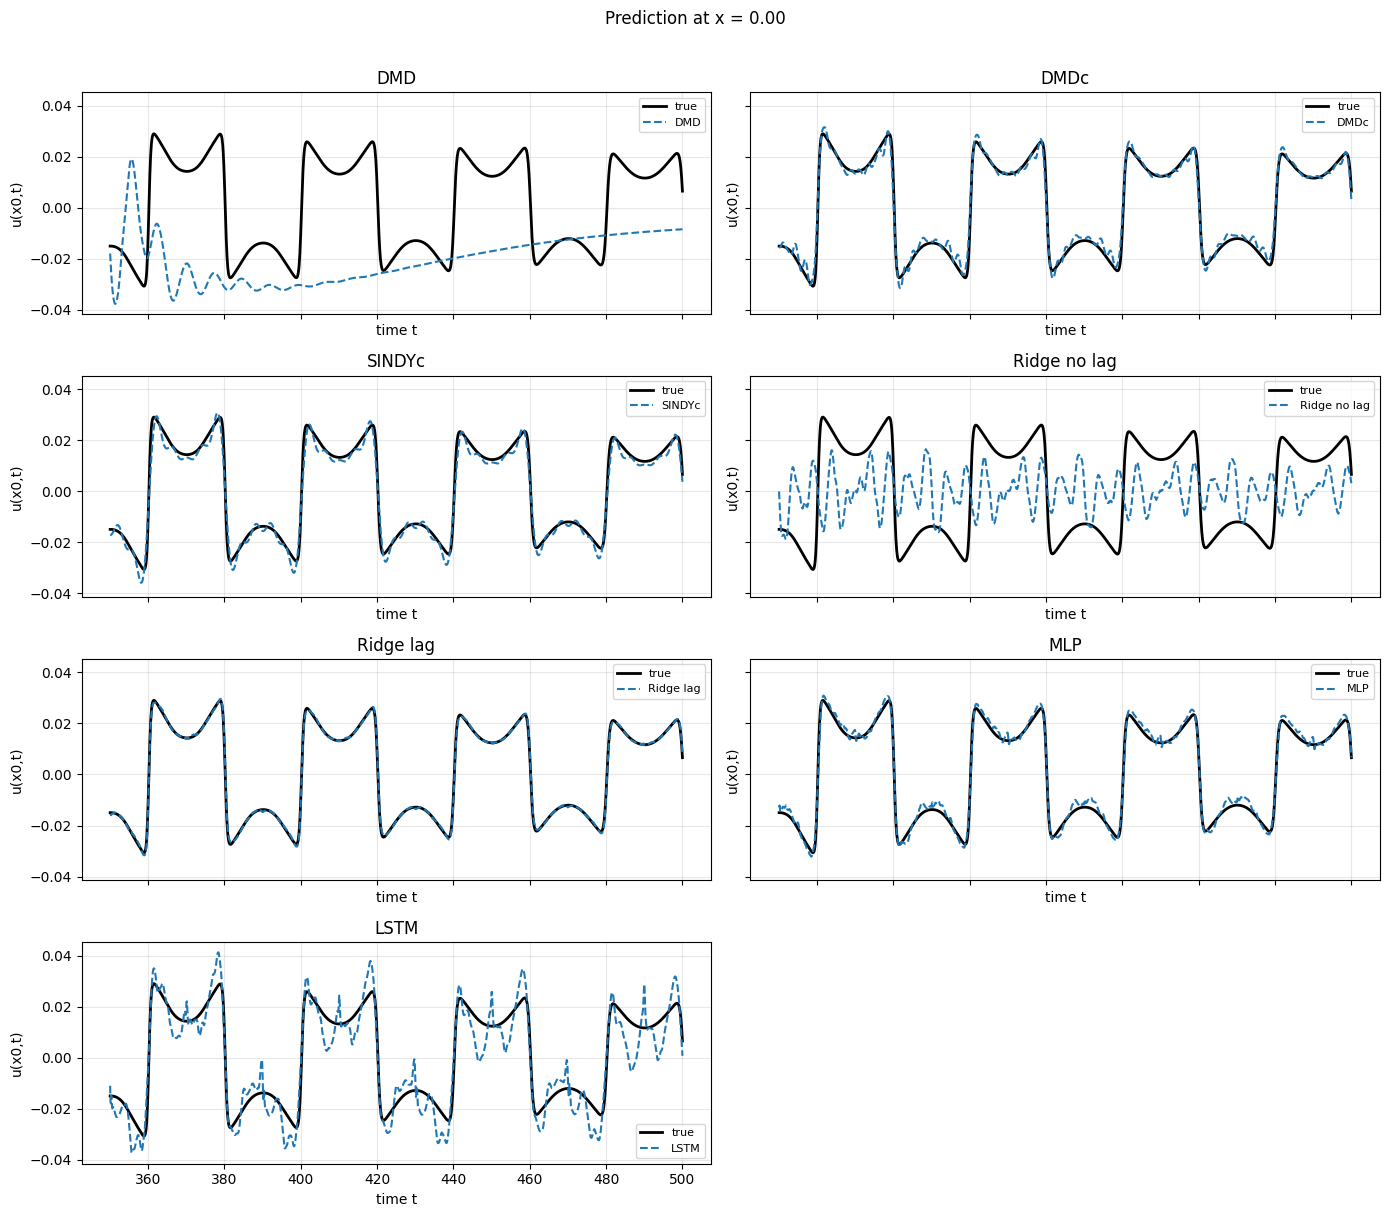

In [39]:
# Time signal at one spatial location, one subplot per method.
x_value = 0.0
x_index = int(np.argmin(np.abs(x - x_value)))
methods_available = [method for method in METHOD_ORDER if method in clean_predictions]

ncols = 2
nrows = int(np.ceil(len(methods_available) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.0 * nrows), sharex=True, sharey=True)
axes = np.asarray(axes).ravel()

for ax, method in zip(axes, methods_available):
    ax.plot(t_test, U_test[x_index, :], "k", linewidth=2, label="true")
    ax.plot(t_test, clean_predictions[method][x_index, :], "--", label=method)
    ax.set_title(method)
    ax.set_xlabel("time t")
    ax.set_ylabel("u(x0,t)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[len(methods_available):]:
    ax.axis("off")

fig.suptitle("Prediction at x = %.2f" % x[x_index], y=1.01)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "final_point_predictions_by_method.png", dpi=120, bbox_inches="tight")
plt.show()

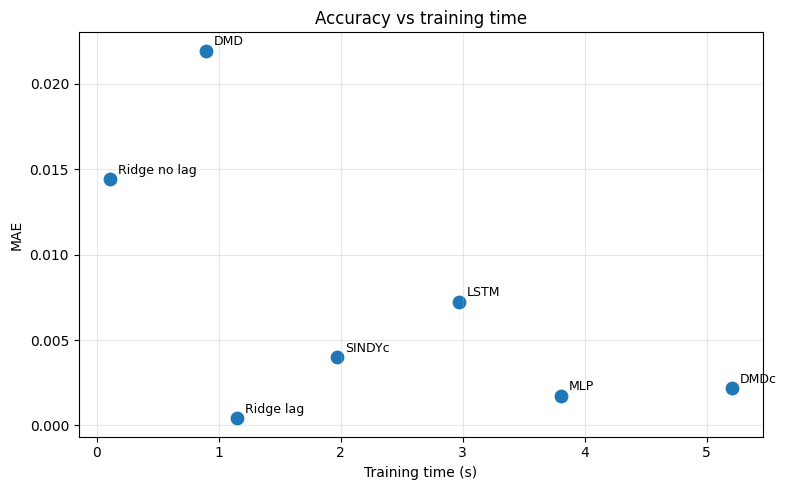

In [36]:
# Accuracy vs training time for clean-data results.
plot_data = clean_results.copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(plot_data["train_time"], plot_data["mae"], s=80)

for _, row in plot_data.iterrows():
    ax.annotate(
        row["method"],
        (row["train_time"], row["mae"]),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=9,
    )

ax.set_xlabel("Training time (s)")
ax.set_ylabel("MAE")
ax.set_title("Accuracy vs training time")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "final_mae_vs_training_time.png", dpi=120)
plt.show()